# Whole-pipeline threshold evaluation

This notebook evaluates the **entire prediction cascade** (`Pipeline.run` in
`phishing_engine/core/pipeline.py`) end-to-end and sweeps its decision **threshold** to
find the value that maximizes phishing **F1**.

**How this differs from `model_evaluation.ipynb`.** That notebook benchmarks each stage's
model *in isolation*. This one exercises the real decision logic: stages run in order
`url -> domain -> content`; a stage with `P(phish) >= threshold` **early-exits** with a
`phish` verdict; otherwise the URL escalates, and if no stage exits the cascade
**aggregates** every stage's probability (`max`/`median` per `decision.fallback_aggregation`)
against the fixed `FALLBACK_DECISION_BOUNDARY` (0.5).

**Method (matches the user-approved plan).**
1. Extract all three stages' features for every labeled URL using the engine's own
   extractors (train/predict parity), keyed per-URL.
2. Split **grouped by domain** (no domain in two splits) into train / validation / test,
   so url, domain *and* content stages are leakage-free.
3. Train fresh per-stage models on the train split.
4. Score per-URL stage probabilities on validation/test and **replay the real cascade**
   by reusing `Pipeline._build_result` (so the verdict can't drift from production).
5. Sweep the threshold on validation, pick the **max-F1** value, and report final metrics
   on the held-out test split (vs. the shipped `decision.threshold`).

**Prerequisites:** MongoDB running with collected, labeled data; run with the project's
`.venv` kernel; working directory = repo root (where `config/pipeline.json` lives).

In [1]:
import os, sys, time, warnings
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

# Make the project importable when the kernel's cwd is the repo root.
sys.path.insert(0, os.path.abspath("."))

import phishing_engine.stages  # noqa: F401  (registers url/domain/content stages)
from phishing_engine.core.config import load_config
from phishing_engine.core.registry import get_stage
from phishing_engine.core.pipeline import Pipeline, PipelineContext, FALLBACK_DECISION_BOUNDARY
from phishing_engine.storage.mongo import MongoStore

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (precision_score, recall_score, f1_score, accuracy_score,
                             confusion_matrix, ConfusionMatrixDisplay, classification_report)

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110
print("imports ok; FALLBACK_DECISION_BOUNDARY =", FALLBACK_DECISION_BOUNDARY)

imports ok; FALLBACK_DECISION_BOUNDARY = 0.5


## Parameters

In [2]:
CONFIG_PATH = "config/pipeline.json"
# Cap on labeled docs (0 = all). Override with PHISH_EVAL_LIMIT for a quick smoke run.
LIMIT       = int(os.environ.get("PHISH_EVAL_LIMIT", "0"))
RS          = 42          # shared random_state for the split + every model
MODEL_TYPE  = "lightgbm"  # lightgbm | random_forest | gradient_boosting | xgboost

# Domain-grouped split fractions (must sum to 1.0). No domain crosses splits.
TRAIN_FRAC, VAL_FRAC, TEST_FRAC = 0.6, 0.2, 0.2

# Grid swept over the cascade's early-exit threshold.
THRESHOLDS    = np.round(np.linspace(0.0, 1.0, 101), 4)
RECALL_TARGET = 0.95      # secondary operating point: best precision with recall >= this

# Joint per-URL feature cache (extraction over thousands of docs is the slow part).
FEATURE_CACHE_DIR = "feature_cache"
USE_FEATURE_CACHE = True
FORCE_RECALC      = False
print(f"LIMIT={LIMIT}  MODEL_TYPE={MODEL_TYPE}  split={TRAIN_FRAC}/{VAL_FRAC}/{TEST_FRAC}")

LIMIT=0  MODEL_TYPE=lightgbm  split=0.6/0.2/0.2


## Connect to MongoDB and read the decision policy

The threshold/labels/aggregation come straight from the config's `pipeline.decision`
block, so the sweep is measured against the exact policy the engine ships with.

In [3]:
config   = load_config(CONFIG_PATH)
mongo    = config.pipeline.mongo
DECISION = config.pipeline.decision
STAGE_CONFIGS = {s.id: s for s in config.pipeline.stages}
POSITIVE = DECISION.positive_label   # "phish"
NEGATIVE = DECISION.negative_label   # "benign"
CURRENT_THRESHOLD = DECISION.threshold

store = MongoStore(mongo.uri, mongo.database, mongo.collection, mongo.domain_collection)
print(f"db={mongo.database!r} urls={mongo.collection!r} domains={mongo.domain_collection!r}")
print(f"decision: threshold={DECISION.threshold} positive={POSITIVE!r} "
      f"negative={NEGATIVE!r} fallback_aggregation={DECISION.fallback_aggregation!r}")
print("labeled docs with a domain record:", store.count_labeled(require="domain_record", limit=LIMIT))

db='phishing_engine' urls='url_documents' domains='domain_records'
decision: threshold=0.8 positive='phish' negative='benign' fallback_aggregation='mean'
labeled docs with a domain record: 7394


## Joint per-URL feature extraction

One pass over `iter_labeled(require="domain_record")` (which `$lookup`-joins the domain
record and still carries `raw.content` when present). For each URL we run the **same**
extractors the training/prediction pipelines use and key everything by URL `_id`:

- **url** features from the URL string (always available),
- **domain** features from `raw.domain_record` (identical for every URL of a host),
- **content** features from `raw.content` when the page was collected.

`domain_ok` / `content_ok` record whether a stage produced features; a stage with no
features contributes no probability later (mirroring the cascade's "escalate" path). The
aligned matrices are cached to `feature_cache/` so re-runs skip the slow extraction.

In [4]:
URL_COLS     = STAGE_CONFIGS["url"].feature_columns
CONTENT_COLS = STAGE_CONFIGS["content"].feature_columns   # domain stage has no fixed columns

def _align(df, cols):
    '''Coerce to numeric (bools->0/1); if cols given, add missing + order to them, drop extras.

    Mirrors the coercion in core/training.py so the offline features match training exactly.
    '''
    df = df.replace({True: 1, False: 0})
    if cols:
        for c in cols:
            if c not in df.columns:
                df[c] = 0
        df = df[cols]
    return df.apply(pd.to_numeric, errors="coerce").fillna(0.0)

def _cache_paths(limit):
    suf = f"_lim{limit}" if limit else ""
    base = os.path.join(FEATURE_CACHE_DIR, f"pipeline_joint{suf}")
    return {k: f"{base}_{k}.csv" for k in ("meta", "url", "domain", "content")}

def build_joint_dataset(limit=LIMIT):
    paths = _cache_paths(limit)
    if USE_FEATURE_CACHE and not FORCE_RECALC and all(os.path.exists(p) for p in paths.values()):
        meta = pd.read_csv(paths["meta"])
        url_df, dom_df, con_df = (pd.read_csv(paths[k]) for k in ("url", "domain", "content"))
        print(f"[cache] loaded joint dataset: {len(meta)} URLs  ({FEATURE_CACHE_DIR}/)")
        return meta, url_df, dom_df, con_df

    url_stage = get_stage("url")(STAGE_CONFIGS["url"], None)
    dom_stage = get_stage("domain")(STAGE_CONFIGS["domain"], None)
    con_stage = get_stage("content")(STAGE_CONFIGS["content"], None)

    ids, refs, labels, has_content, dom_ok, con_ok = [], [], [], [], [], []
    url_rows, dom_rows, con_rows = [], [], []
    failed = 0
    t0 = time.perf_counter()
    total = store.count_labeled(require="domain_record", limit=limit)
    it = tqdm(store.iter_labeled(require="domain_record", limit=limit),
              total=total, desc="extracting features", unit="doc")
    for doc in it:
        label = doc.get("label")
        if label not in ("phish", "benign"):
            continue
        ctx = PipelineContext(url=doc.get("url", ""), normalized_url=doc["_id"],
                              domain=doc.get("domain", ""), label=label)
        raw = doc.get("raw") or {}
        try:
            u = url_stage.extract_features(ctx, {})
        except Exception:
            failed += 1
            continue
        try:
            d = dom_stage.extract_features(ctx, dom_stage.build_train_artifacts(doc))
        except Exception:
            d = {}
        if raw.get("content") is not None:
            try:
                c = con_stage.extract_features(ctx, con_stage.build_train_artifacts(doc))
            except Exception:
                c = {}
            hc = True
        else:
            c, hc = {}, False

        ids.append(doc["_id"]); refs.append(raw.get("domain_record_ref")); labels.append(label)
        has_content.append(hc); dom_ok.append(bool(d)); con_ok.append(hc and bool(c))
        url_rows.append(u); dom_rows.append(d); con_rows.append(c)

    print(f"extracted {len(ids)} URLs in {time.perf_counter() - t0:.0f}s "
          f"({failed} url-extraction failures skipped)")

    meta = pd.DataFrame({"_id": ids, "domain_ref": refs, "_label": labels,
                         "has_content": has_content, "domain_ok": dom_ok, "content_ok": con_ok})
    url_df = _align(pd.DataFrame(url_rows), URL_COLS)
    dom_df = _align(pd.DataFrame(dom_rows), None)          # keep extractor-produced columns
    con_df = _align(pd.DataFrame(con_rows), CONTENT_COLS)

    if USE_FEATURE_CACHE:
        os.makedirs(FEATURE_CACHE_DIR, exist_ok=True)
        meta.to_csv(paths["meta"], index=False)
        url_df.to_csv(paths["url"], index=False)
        dom_df.to_csv(paths["domain"], index=False)
        con_df.to_csv(paths["content"], index=False)
        print(f"[cache] saved joint dataset -> {FEATURE_CACHE_DIR}/")
    return meta, url_df, dom_df, con_df

meta, url_df, dom_df, con_df = build_joint_dataset()

# Positional alignment across every frame (index == row position).
meta   = meta.reset_index(drop=True)
url_df = url_df.reset_index(drop=True)
dom_df = dom_df.reset_index(drop=True)
con_df = con_df.reset_index(drop=True)
y = (meta["_label"].to_numpy() == POSITIVE).astype(int)

print("shapes:", {"meta": meta.shape, "url": url_df.shape,
                  "domain": dom_df.shape, "content": con_df.shape})
print(f"phish={int(y.sum())} benign={int((y == 0).sum())} | "
      f"with content={int(meta['has_content'].sum())} | "
      f"domain_ok={int(meta['domain_ok'].sum())} content_ok={int(meta['content_ok'].sum())}")

[cache] loaded joint dataset: 7084 URLs  (feature_cache/)
shapes: {'meta': (7084, 6), 'url': (7084, 39), 'domain': (7084, 136), 'content': (7084, 111)}
phish=1601 benign=5483 | with content=6697 | domain_ok=7084 content_ok=6697


## Domain-grouped train / validation / test split

`GroupShuffleSplit` with `groups = domain_ref` guarantees **no domain appears in more than
one split**. That is the leakage guard for every stage: domain features are identical
within a host, and url/content examples are host-tied, so a per-URL random split would let
the models memorize hosts. We select the threshold on **validation** and report final
numbers on **test**, so the chosen "optimal" isn't scored on the data that picked it.

In [5]:
assert abs(TRAIN_FRAC + VAL_FRAC + TEST_FRAC - 1.0) < 1e-9, "split fractions must sum to 1"
groups = meta["domain_ref"].fillna(meta["_id"]).to_numpy()   # fall back to _id if ref missing

# 1) train vs (val + test)
gss1 = GroupShuffleSplit(n_splits=1, train_size=TRAIN_FRAC, random_state=RS)
train_idx, temp_idx = next(gss1.split(meta, y, groups))
# 2) split the remainder into val vs test
rel_val = VAL_FRAC / (VAL_FRAC + TEST_FRAC)
gss2 = GroupShuffleSplit(n_splits=1, train_size=rel_val, random_state=RS)
v_rel, t_rel = next(gss2.split(temp_idx, y[temp_idx], groups[temp_idx]))
val_idx, test_idx = temp_idx[v_rel], temp_idx[t_rel]

for name, idx in [("train", train_idx), ("val", val_idx), ("test", test_idx)]:
    yy = y[idx]
    assert set(np.unique(yy)) == {0, 1}, f"{name} split is single-class; adjust seed/LIMIT"
    print(f"{name:5}: {len(idx):5} URLs  ({len(np.unique(groups[idx])):4} domains)  "
          f"phish={int(yy.sum())} benign={int((yy == 0).sum())}")

assert not (set(groups[train_idx]) & set(groups[val_idx])),  "domain leak train/val"
assert not (set(groups[train_idx]) & set(groups[test_idx])), "domain leak train/test"
assert not (set(groups[val_idx])   & set(groups[test_idx])), "domain leak val/test"
print("no domain crosses splits -> leakage-free")

train:  4208 URLs  (2301 domains)  phish=941 benign=3267
val  :  1265 URLs  ( 767 domains)  phish=311 benign=954
test :  1611 URLs  ( 767 domains)  phish=349 benign=1262
no domain crosses splits -> leakage-free


## Train fresh per-stage models on the train split

Each stage is trained exactly as the production training pipeline would, but only on the
train domains:

- **url** / **content**: one row per URL (content only on URLs whose page was collected).
- **domain**: deduplicated to one row per `domain_ref`, labeled `phish` if *any* URL of
  that domain is phish (matching `collect_training_data` in `core/training.py`).

Labels are encoded as `1=phish / 0=benign` so any classifier (incl. XGBoost) trains
uniformly; `phish_proba` reads the phish column back via `model.classes_`.

In [6]:
def make_model(kind=MODEL_TYPE):
    if kind == "lightgbm":
        from lightgbm import LGBMClassifier
        return LGBMClassifier(n_estimators=400, learning_rate=0.05, n_jobs=-1,
                              random_state=RS, verbose=-1)
    if kind == "random_forest":
        from sklearn.ensemble import RandomForestClassifier
        return RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=RS)
    if kind == "gradient_boosting":
        from sklearn.ensemble import GradientBoostingClassifier
        return GradientBoostingClassifier(random_state=RS)
    if kind == "xgboost":
        from xgboost import XGBClassifier
        return XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.1,
                             subsample=0.9, colsample_bytree=0.9, eval_metric="logloss",
                             tree_method="hist", n_jobs=-1, random_state=RS)
    raise ValueError(f"unknown MODEL_TYPE: {kind}")

def phish_proba(model, X):
    '''P(phish) column, located via model.classes_ (labels are 1=phish / 0=benign).'''
    idx = list(model.classes_).index(1)
    return model.predict_proba(X)[:, idx]

# ---- url: per-URL ----
assert set(y[train_idx]) == {0, 1}
url_model = make_model().fit(url_df.iloc[train_idx], y[train_idx])

# ---- domain: dedup train to one row per domain_ref (phish if any URL of the ref is phish) ----
tm = meta.iloc[train_idx]
rep_rows, rep_labels = [], []
for ref, sub in tm.groupby("domain_ref"):
    ok = sub.index[sub["domain_ok"].to_numpy()]
    if len(ok) == 0:
        continue                                  # this domain produced no features
    rep_rows.append(int(ok[0]))                   # features identical within a domain
    rep_labels.append(1 if (sub["_label"] == POSITIVE).any() else 0)
rep_labels = np.array(rep_labels)
assert set(rep_labels) == {0, 1}, "domain train split single-class; adjust seed/LIMIT"
dom_model = make_model().fit(dom_df.loc[rep_rows], rep_labels)

# ---- content: per-URL, only rows whose page was collected ----
con_train = [int(i) for i in train_idx if meta.at[int(i), "content_ok"]]
assert set(y[con_train]) == {0, 1}, "content train split single-class; adjust seed/LIMIT"
con_model = make_model().fit(con_df.loc[con_train], y[con_train])

print(f"trained {MODEL_TYPE}:  url={len(train_idx)} rows  "
      f"domain={len(rep_rows)} unique-domain rows "
      f"(phish={int(rep_labels.sum())}/benign={int((rep_labels == 0).sum())})  "
      f"content={len(con_train)} rows")

trained lightgbm:  url=4208 rows  domain=2301 unique-domain rows (phish=729/benign=1572)  content=3979 rows


## Score per-URL stage probabilities and assemble the cascade inputs

For each URL we build the ordered list `[("url", p), ("domain", p), ("content", p)]`,
**omitting** any stage that produced no features (`domain_ok` / `content_ok` False) -- the
cascade treats a stage with no usable probability as "escalate", so it must not appear.

In [7]:
def stage_probs_for(idx):
    '''Per-URL ordered [(stage, P(phish)), ...] for the rows in `idx`.'''
    pu = phish_proba(url_model, url_df.iloc[idx])
    pd_ = phish_proba(dom_model, dom_df.iloc[idx])
    pc = phish_proba(con_model, con_df.iloc[idx])
    dok = meta["domain_ok"].to_numpy()[idx]
    cok = meta["content_ok"].to_numpy()[idx]
    out = []
    for k in range(len(idx)):
        lst = [("url", float(pu[k]))]
        if dok[k]:
            lst.append(("domain", float(pd_[k])))
        if cok[k]:
            lst.append(("content", float(pc[k])))
        out.append(lst)
    return out

val_probs     = stage_probs_for(val_idx)
test_probs    = stage_probs_for(test_idx)
y_val, y_test = y[val_idx], y[test_idx]
print(f"assembled prob lists: val={len(val_probs)} test={len(test_probs)}")
print("example (val[0]):", val_probs[0])

assembled prob lists: val=1265 test=1611
example (val[0]): [('url', 1.413249275270585e-07), ('domain', 3.7109508218614063e-05), ('content', 2.109366252643247e-06)]


## Cascade replay (reuses the production decision logic)

`cascade()` rebuilds the `(stage, p)` list and `early_exit` exactly as the loop in
`Pipeline.run` does, then defers to `Pipeline._build_result` for the verdict -- the same
aggregation and the fixed `FALLBACK_DECISION_BOUNDARY`. So the offline verdict is identical
to production by construction; only the early-exit threshold is varied.

Note the documented invariant: with `max` aggregation the cascade reduces to
`phish  <=>  max(stage probs) >= min(threshold, 0.5)`, so thresholds above 0.5 are
equivalent and the meaningful knob lives in `(0, 0.5]`. The sweep curve makes this visible
(a flat region above 0.5).

In [8]:
_replay = Pipeline(stages=[], decision=DECISION)
_ctx = PipelineContext(url="", normalized_url="", domain="")

def cascade(prob_list, threshold):
    '''Return (decision, stage_id, route) for one URL at a given early-exit threshold.'''
    collected, early_exit = [], None
    for sid, p in prob_list:
        collected.append((sid, p))
        if p >= threshold:
            early_exit = (sid, p)
            break
    res = _replay._build_result(_ctx, collected, early_exit)
    if early_exit is not None:
        route = "early_exit"
    elif res.decision == "unknown":
        route = "unknown"
    else:
        route = "fallback"
    return res.decision, res.stage_id, route

# spot-check: the URL with the highest url probability should early-exit phish at 0.5
_demo = max(val_probs, key=lambda L: L[0][1])
print("highest-url-prob demo:", _demo, "->", cascade(_demo, 0.5))

highest-url-prob demo: [('url', 0.9999993561412159), ('domain', 0.9999999421406058), ('content', 0.9999989696018007)] -> ('phish', 'url', 'early_exit')


## Threshold sweep on the validation split

For every candidate threshold we replay the cascade over all validation URLs and score the
phishing class (`phish = positive`; an `unknown` verdict counts as negative and is tallied
separately). The headline "optimal" is the **max-F1** threshold.

In [9]:
def evaluate(prob_lists, y_true, threshold):
    preds, routes = [], []
    for L in prob_lists:
        dec, _sid, route = cascade(L, threshold)
        preds.append(1 if dec == POSITIVE else 0)
        routes.append(route)
    preds = np.asarray(preds)
    return {
        "threshold":  threshold,
        "precision":  precision_score(y_true, preds, zero_division=0),
        "recall":     recall_score(y_true, preds, zero_division=0),
        "f1":         f1_score(y_true, preds, zero_division=0),
        "accuracy":   accuracy_score(y_true, preds),
        "pred_phish": int(preds.sum()),
        "n_unknown":  int(sum(r == "unknown" for r in routes)),
    }

sweep = pd.DataFrame([evaluate(val_probs, y_val, t) for t in THRESHOLDS])
best_row = sweep.loc[sweep["f1"].idxmax()]
BEST_T = float(best_row["threshold"])
print(f"validation F1-optimal threshold = {BEST_T:.4f}  "
      f"(F1={best_row['f1']:.4f}  P={best_row['precision']:.4f}  R={best_row['recall']:.4f})")

# secondary operating point: best precision while recall >= RECALL_TARGET
ok = sweep[sweep["recall"] >= RECALL_TARGET]
if len(ok):
    alt = ok.loc[ok["precision"].idxmax()]
    print(f"best precision @ recall>={RECALL_TARGET}: threshold={alt['threshold']:.4f}  "
          f"(P={alt['precision']:.4f}  R={alt['recall']:.4f}  F1={alt['f1']:.4f})")
else:
    print(f"no threshold reaches recall >= {RECALL_TARGET}")

# show a coarse view of the curve plus the winning row
view = sweep.iloc[::5].copy()
if BEST_T not in set(view["threshold"]):
    view = pd.concat([view, best_row.to_frame().T]).sort_values("threshold")
view.round(4)

validation F1-optimal threshold = 0.9900  (F1=0.9696  P=0.9650  R=0.9743)
best precision @ recall>=0.95: threshold=0.9900  (P=0.9650  R=0.9743  F1=0.9696)


,threshold,precision,recall,f1,accuracy,pred_phish,n_unknown
0,0.00,0.9441,0.9228,0.9333,0.9676,304.0,0.0
5,0.05,0.8875,0.9389,0.9125,0.9557,329.0,0.0
10,0.10,0.8852,0.9421,0.9128,0.9557,331.0,0.0
15,0.15,0.8862,0.9518,0.9178,0.9581,334.0,0.0
20,0.20,0.8872,0.9614,0.9228,0.9605,337.0,0.0
25,0.25,0.8872,0.9614,0.9228,0.9605,337.0,0.0
30,0.30,0.8889,0.9775,0.9311,0.9644,342.0,0.0
35,0.35,0.8892,0.9807,0.9327,0.9652,343.0,0.0
40,0.40,0.8895,0.9839,0.9344,0.9660,344.0,0.0
45,0.45,0.8895,0.9839,0.9344,0.9660,344.0,0.0


## Metrics vs. threshold (validation)

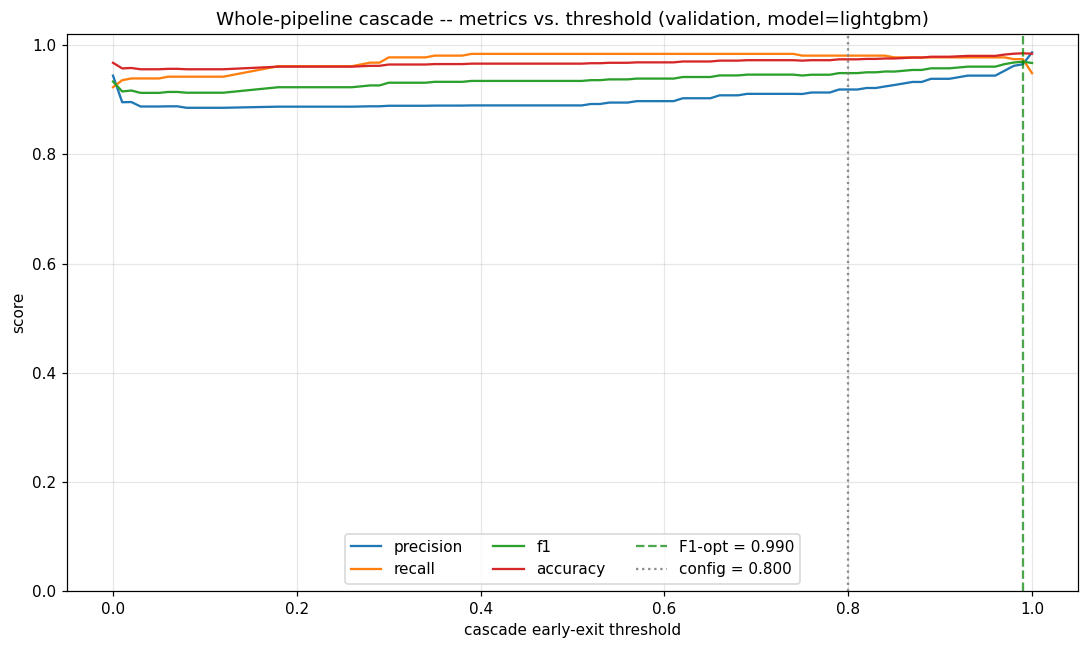

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))
for m, c in [("precision", "tab:blue"), ("recall", "tab:orange"),
             ("f1", "tab:green"), ("accuracy", "tab:red")]:
    ax.plot(sweep["threshold"], sweep[m], label=m, color=c)
ax.axvline(BEST_T, ls="--", color="green", alpha=0.7, label=f"F1-opt = {BEST_T:.3f}")
ax.axvline(CURRENT_THRESHOLD, ls=":", color="gray", alpha=0.9,
           label=f"config = {CURRENT_THRESHOLD:.3f}")
ax.set_xlabel("cascade early-exit threshold"); ax.set_ylabel("score")
ax.set_title(f"Whole-pipeline cascade -- metrics vs. threshold (validation, model={MODEL_TYPE})")
ax.set_ylim(0, 1.02); ax.grid(alpha=0.3); ax.legend(loc="lower center", ncol=3)
plt.tight_layout(); plt.show()

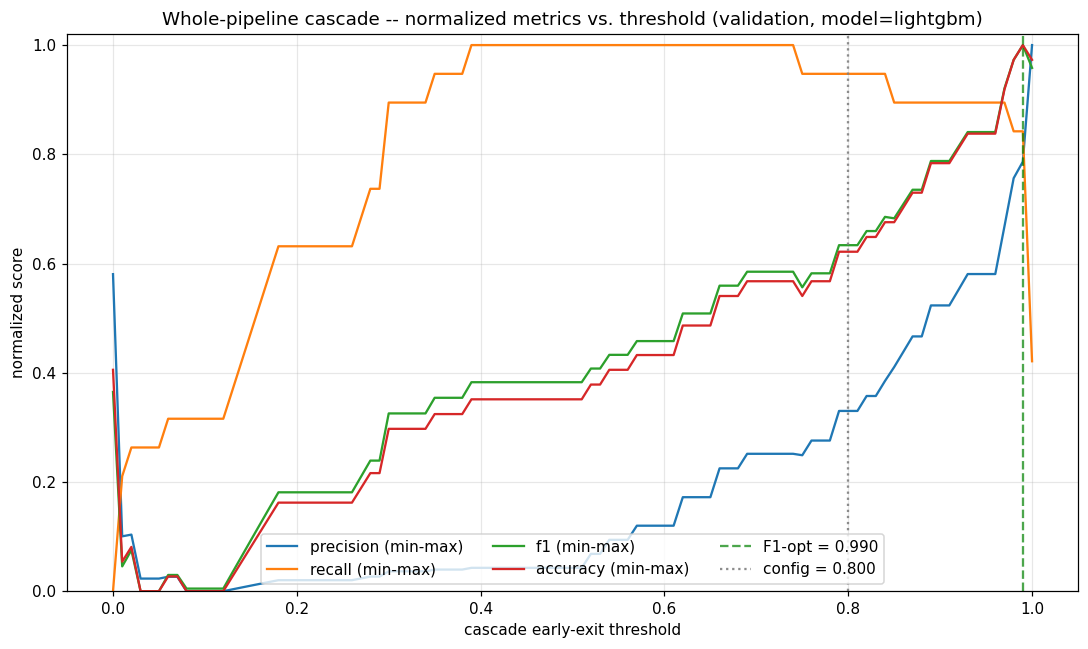

In [16]:
# Min-max normalize each metric across thresholds to compare shapes.
metrics = ["precision", "recall", "f1", "accuracy"]
norm = sweep[["threshold", *metrics]].copy()
for m in metrics:
    vals = norm[m].to_numpy()
    vmin = np.nanmin(vals)
    vmax = np.nanmax(vals)
    if np.isclose(vmax - vmin, 0):
        norm[m] = 0.0
    else:
        norm[m] = (vals - vmin) / (vmax - vmin)

fig, ax = plt.subplots(figsize=(10, 6))
for m, c in [("precision", "tab:blue"), ("recall", "tab:orange"),
             ("f1", "tab:green"), ("accuracy", "tab:red")]:
    ax.plot(norm["threshold"], norm[m], label=f"{m} (min-max)", color=c)
ax.axvline(BEST_T, ls="--", color="green", alpha=0.7, label=f"F1-opt = {BEST_T:.3f}")
ax.axvline(CURRENT_THRESHOLD, ls=":", color="gray", alpha=0.9,
           label=f"config = {CURRENT_THRESHOLD:.3f}")
ax.set_xlabel("cascade early-exit threshold"); ax.set_ylabel("normalized score")
ax.set_title(
    f"Whole-pipeline cascade -- normalized metrics vs. threshold (validation, model={MODEL_TYPE})"
 )
ax.set_ylim(0, 1.02); ax.grid(alpha=0.3); ax.legend(loc="lower center", ncol=3)
plt.tight_layout(); plt.show()

## Final report on the held-out test split

Apply the validation-chosen threshold to the **test** split and compare it against the
shipped `decision.threshold`, so the recommended config change is explicit.

In [11]:
def predict_at(prob_lists, threshold):
    return np.asarray([1 if cascade(L, threshold)[0] == POSITIVE else 0 for L in prob_lists])

def metrics_at(y_true, preds):
    return {"precision": precision_score(y_true, preds, zero_division=0),
            "recall":    recall_score(y_true, preds, zero_division=0),
            "f1":        f1_score(y_true, preds, zero_division=0),
            "accuracy":  accuracy_score(y_true, preds)}

preds_opt = predict_at(test_probs, BEST_T)
preds_cur = predict_at(test_probs, CURRENT_THRESHOLD)
cm_opt, cm_cur = confusion_matrix(y_test, preds_opt), confusion_matrix(y_test, preds_cur)

print(f"=== TEST @ F1-optimal threshold = {BEST_T:.4f} ===")
print(classification_report(y_test, preds_opt, target_names=[NEGATIVE, POSITIVE], digits=4))
print(f"=== TEST @ shipped config threshold = {CURRENT_THRESHOLD} ===")
print(classification_report(y_test, preds_cur, target_names=[NEGATIVE, POSITIVE], digits=4))

summary = pd.DataFrame([
    {"which": "F1-optimal",       "threshold": BEST_T,            **metrics_at(y_test, preds_opt)},
    {"which": "config (shipped)", "threshold": CURRENT_THRESHOLD, **metrics_at(y_test, preds_cur)},
]).set_index("which")
summary.round(4)

=== TEST @ F1-optimal threshold = 0.9900 ===
              precision    recall  f1-score   support

      benign     0.9929    0.9937    0.9933      1262
       phish     0.9770    0.9742    0.9756       349

    accuracy                         0.9894      1611
   macro avg     0.9849    0.9839    0.9844      1611
weighted avg     0.9894    0.9894    0.9894      1611

=== TEST @ shipped config threshold = 0.8 ===
              precision    recall  f1-score   support

      benign     0.9992    0.9802    0.9896      1262
       phish     0.9330    0.9971    0.9640       349

    accuracy                         0.9839      1611
   macro avg     0.9661    0.9887    0.9768      1611
weighted avg     0.9848    0.9839    0.9841      1611



,threshold,precision,recall,f1,accuracy
which,,,,,
F1-optimal,0.99,0.977,0.9742,0.9756,0.9894
config (shipped),0.80,0.933,0.9971,0.9640,0.9839


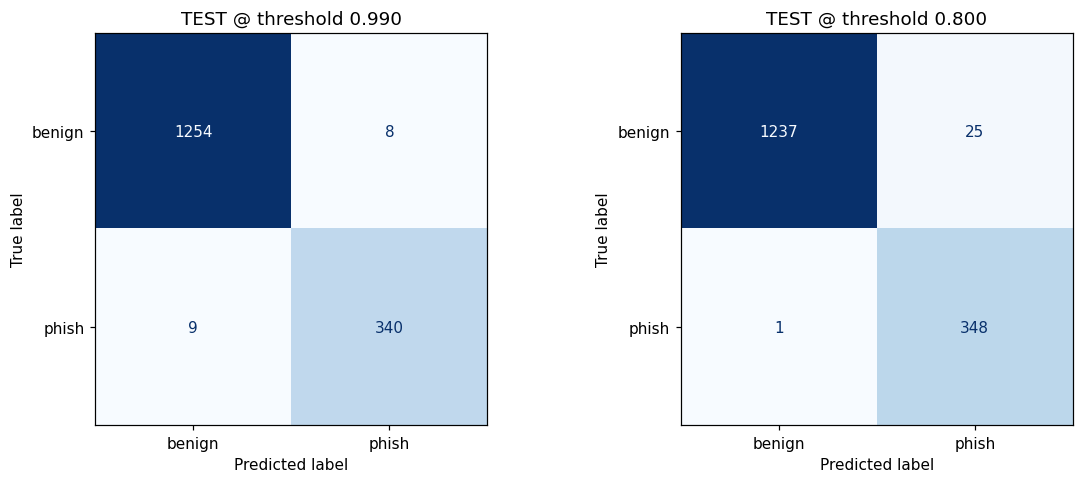

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, cm, t in [(axes[0], cm_opt, BEST_T), (axes[1], cm_cur, CURRENT_THRESHOLD)]:
    ConfusionMatrixDisplay(cm, display_labels=[NEGATIVE, POSITIVE]).plot(
        cmap="Blues", colorbar=False, ax=ax)
    ax.set_title(f"TEST @ threshold {t:.3f}")
plt.tight_layout(); plt.show()

## Cascade decision funnel

How each test URL was decided at the optimal threshold: which stage early-exited it to
`phish`, or whether it fell through to the aggregated fallback. The counts sum to the
number of evaluated URLs.

How the 1611 TEST URLs were decided at threshold 0.9900:


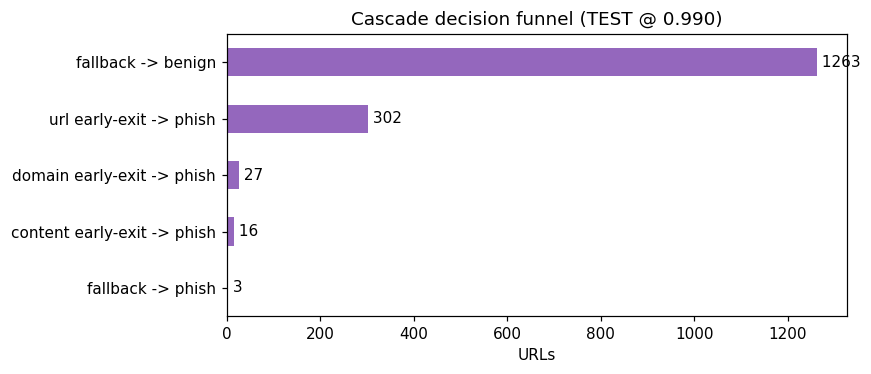

fallback -> benign             1263
url early-exit -> phish         302
domain early-exit -> phish       27
content early-exit -> phish      16
fallback -> phish                 3
dtype: int64

In [13]:
routes = Counter()
for L in test_probs:
    dec, sid, route = cascade(L, BEST_T)
    if route == "early_exit":
        key = f"{sid} early-exit -> phish"
    elif route == "fallback":
        key = f"fallback -> {dec}"
    else:
        key = "unknown"
    routes[key] += 1

funnel = pd.Series(routes).sort_values(ascending=False)
assert funnel.sum() == len(test_probs)
print(f"How the {len(test_probs)} TEST URLs were decided at threshold {BEST_T:.4f}:")
ax = funnel.iloc[::-1].plot(kind="barh", figsize=(8, 3.5), color="tab:purple")
ax.set_xlabel("URLs"); ax.set_title(f"Cascade decision funnel (TEST @ {BEST_T:.3f})")
for i, v in enumerate(funnel.iloc[::-1].values):
    ax.text(v, i, f" {v}", va="center")
plt.tight_layout(); plt.show()
funnel

## Save results and close

Writes the sweep table, the test summary, and the recommended threshold to `eval_results/`
(git-ignored). To adopt the optimum, set `pipeline.decision.threshold` in
`config/pipeline.json` to the value printed below.

In [14]:
os.makedirs("eval_results", exist_ok=True)
sweep.to_csv("eval_results/pipeline_threshold_sweep.csv", index=False)
summary.to_csv("eval_results/pipeline_threshold_summary.csv")
with open("eval_results/optimal_threshold.txt", "w") as fh:
    print(f"model_type={MODEL_TYPE}", file=fh)
    print(f"f1_optimal_threshold={BEST_T:.4f}", file=fh)
    print(f"config_threshold={CURRENT_THRESHOLD}", file=fh)
print("saved sweep + summary + optimal_threshold to eval_results/")
print()
print(f">>> Recommended decision.threshold = {BEST_T:.4f}")
print("    (set it in config/pipeline.json -> pipeline.decision.threshold)")
store.close()
print("done")

saved sweep + summary + optimal_threshold to eval_results/

>>> Recommended decision.threshold = 0.9900
    (set it in config/pipeline.json -> pipeline.decision.threshold)
done
